# Exponential self-healing friction law

2025.11.27 Kurama Okubo

This code is made with the support of ChatGPT.

In [1]:
import os
import sys
import shutil
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
%matplotlib inline
import numpy as np
import pandas as pd
from datetime import timedelta
from tqdm import tqdm
import warnings
import time
from datetime import datetime

%load_ext autoreload
%autoreload 2

plt.rcParams["font.family"] = 'Arial'
# plt.rcParams["font.sans-serif"] = "DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif"
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 4.75
plt.rcParams["xtick.major.width"] = 0.75
plt.rcParams["xtick.minor.size"] = 3
plt.rcParams["xtick.minor.width"] = 0.4
plt.rcParams["xtick.minor.visible"] = True

plt.rcParams["ytick.direction"] = "in"
plt.rcParams["ytick.major.size"] = 4.75
plt.rcParams["ytick.major.width"] = 0.75
plt.rcParams["ytick.minor.size"] = 3
plt.rcParams["ytick.minor.width"] = 0.4
plt.rcParams["ytick.minor.visible"] = True

plt.rcParams["savefig.transparent"] = True

plt.rcParams['axes.linewidth'] = 0.75

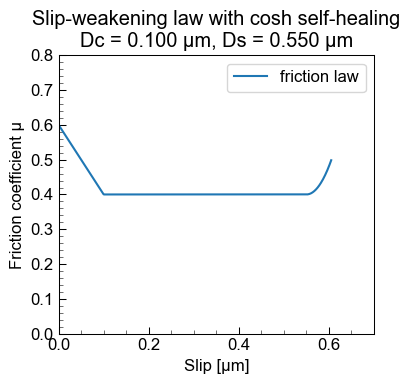

In [145]:
# --- Parameters ----------------------------------------------------
Dc = 0.1e-6             # [m]
Ds = 5.5 * Dc           # [m]

mus = 0.6               # static friction coefficient
muk = 0.4               # kinetic friction coefficient

# healing smoothness parameter (self-healing part)
k_expselfheal = 10.0e6  # [1/m] 例:

# --- Slip range ----------------------------------------------------
# 0 〜 3*Ds くらいまで見ておく
gap = np.linspace(0.0, 1.1 * Ds, 500)  # [m]
mu = np.zeros_like(gap)

# --- Slip-weakening + exp self-healing law ------------------------
for i, g in enumerate(gap):
    if g <= 0.0:
        # 初期状態
        mu[i] = mus

    elif g < Ds:
        # 0 < gap < Ds
        dmu = (1.0 - g / Dc) * (mus - muk)
        mu_tmp = muk + dmu
        mu[i] = max(muk, mu_tmp)

    else:
        # gap >= Ds
        # mu[i] = muk * np.exp(k_expselfheal * (g - Ds))
        k_heal = 8e6
        mu[i] = muk + (np.cosh(k_heal * (g - Ds)) - 1)


# --- Plot ----------------------------------------------------------
plt.figure(figsize=(4, 4))
plt.plot(gap * 1e6, mu, label="friction law")

plt.xlabel("Slip [µm]")
plt.ylabel("Friction coefficient µ")
plt.title("Slip-weakening law with cosh self-healing\n"
          f"Dc = {Dc*1e6:.3f} µm, Ds = {Ds*1e6:.3f} µm")
plt.xlim(0, 0.7)
plt.ylim(0, 0.8)
# plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [146]:
np.tanh(k_expselfheal*(g - Ds))

0.5005202111902353

In [147]:
np.clip(x, -0.999999, 0.05)

array([0.        , 0.0020202 , 0.0040404 , 0.00606061, 0.00808081,
       0.01010101, 0.01212121, 0.01414141, 0.01616162, 0.01818182,
       0.02020202, 0.02222222, 0.02424242, 0.02626263, 0.02828283,
       0.03030303, 0.03232323, 0.03434343, 0.03636364, 0.03838384,
       0.04040404, 0.04242424, 0.04444444, 0.04646465, 0.04848485,
       0.05      , 0.05      , 0.05      , 0.05      , 0.05      ,
       0.05      , 0.05      , 0.05      , 0.05      , 0.05      ,
       0.05      , 0.05      , 0.05      , 0.05      , 0.05      ,
       0.05      , 0.05      , 0.05      , 0.05      , 0.05      ,
       0.05      , 0.05      , 0.05      , 0.05      , 0.05      ,
       0.05      , 0.05      , 0.05      , 0.05      , 0.05      ,
       0.05      , 0.05      , 0.05      , 0.05      , 0.05      ,
       0.05      , 0.05      , 0.05      , 0.05      , 0.05      ,
       0.05      , 0.05      , 0.05      , 0.05      , 0.05      ,
       0.05      , 0.05      , 0.05      , 0.05      , 0.05   

In [148]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))
def sigmoid_inv(y):
  return np.log(y/(1-y))

(0.0, 1.0)

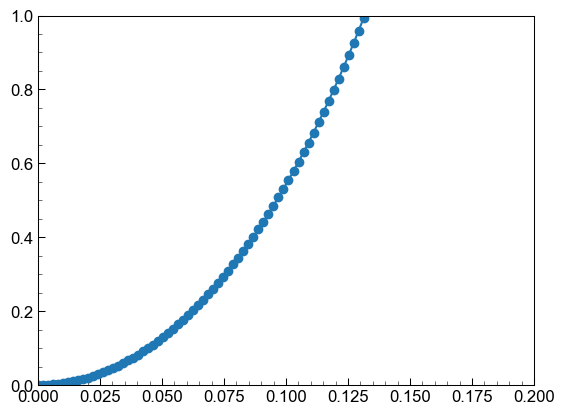

In [135]:
x=np.linspace(0, 0.2, 100)
k_heal = 10
y = np.cosh(k_heal*x)-1
plt.plot(x, y, "o-")

plt.xlim(0, 0.2)
plt.ylim(0, 1.0)